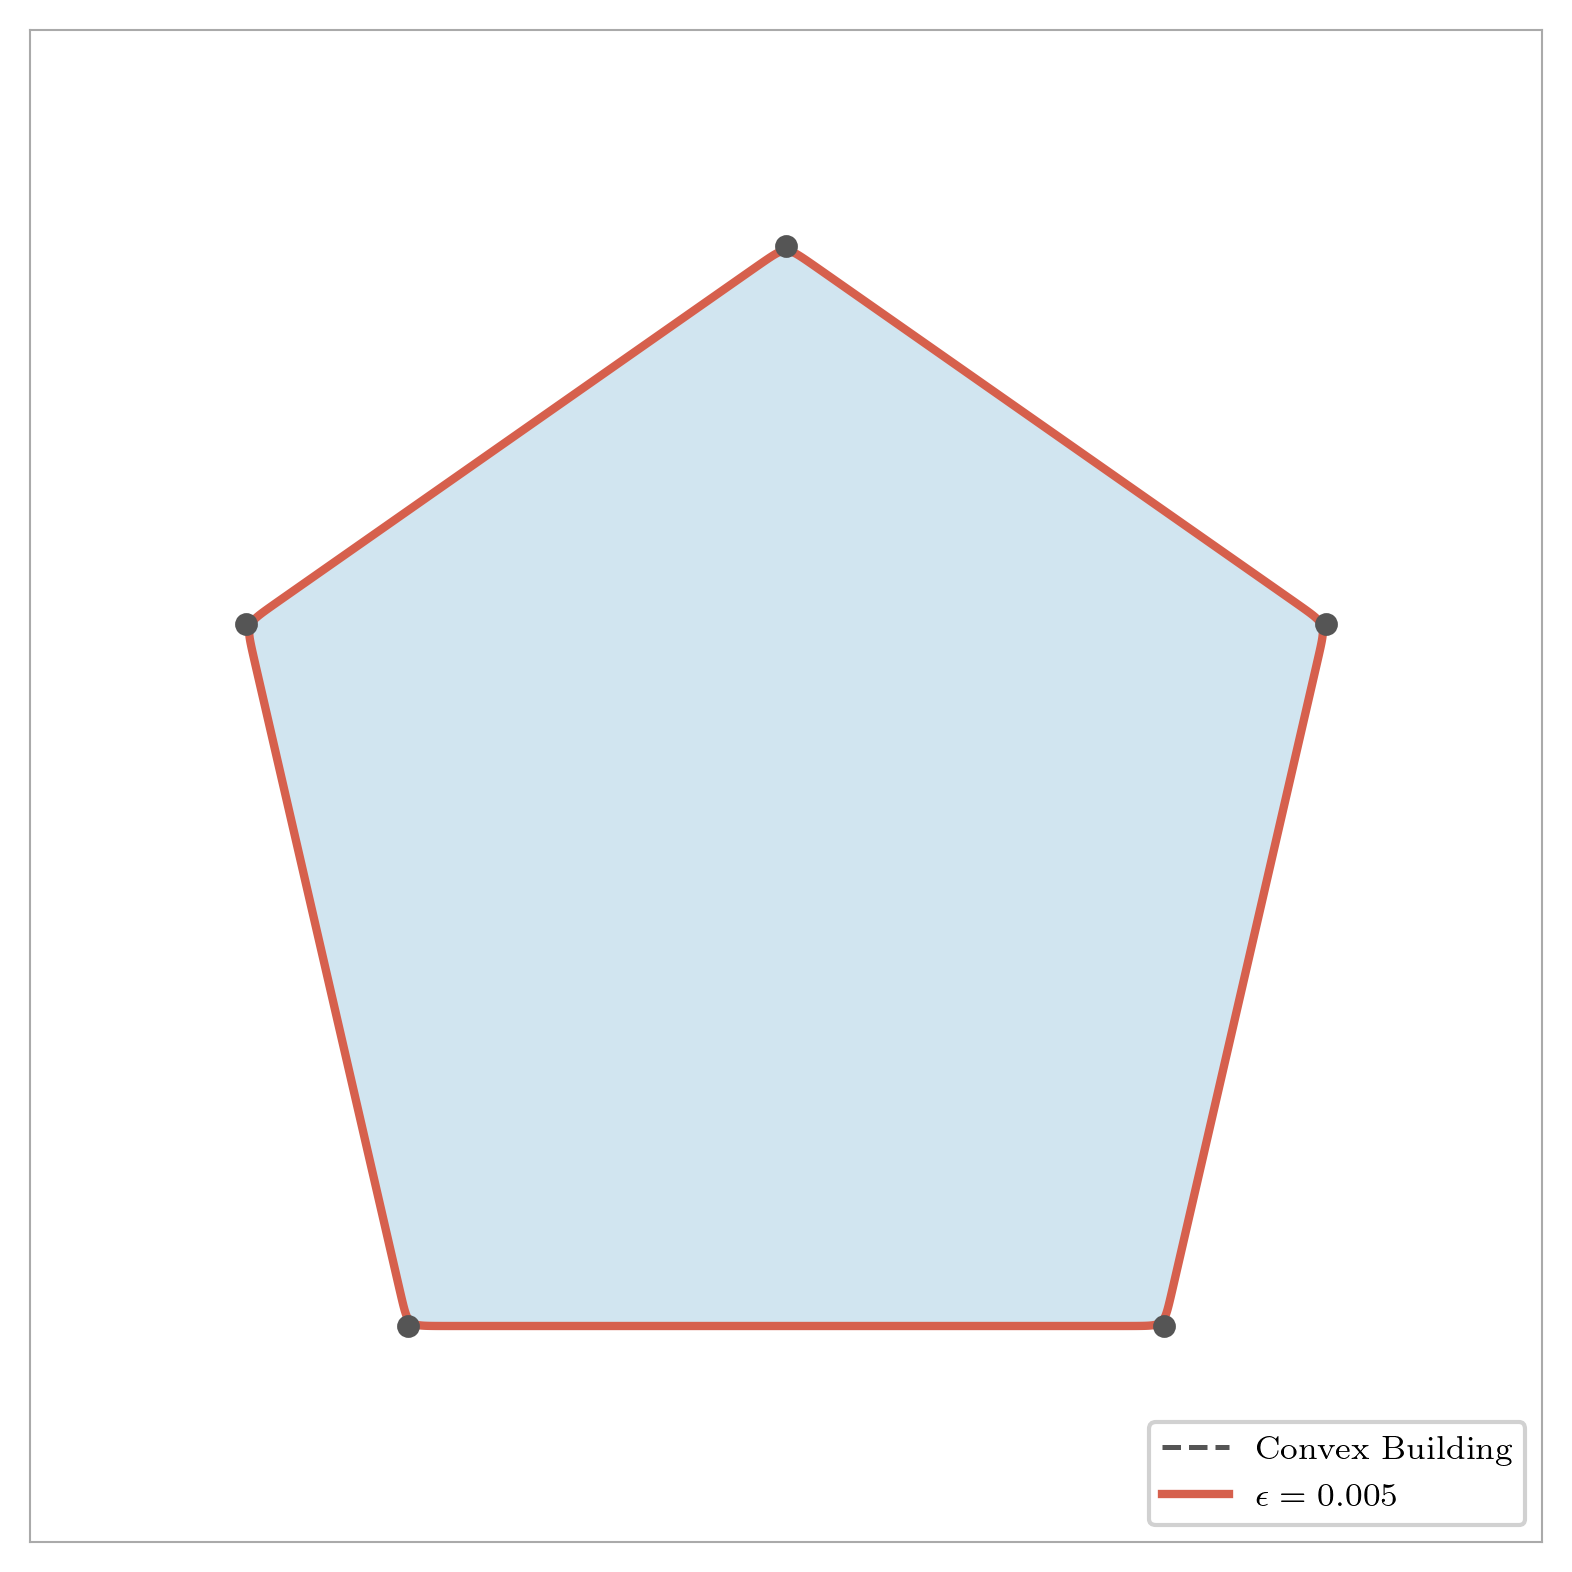

In [22]:
import numpy as np
import matplotlib
matplotlib.rcParams['text.usetex'] = True  # set False if LaTeX not available
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['axes.linewidth'] = 0.5
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.lines import Line2D
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True

# ── USER SETTINGS ────────────────────────────────────────────────────────────
EPSILON = 0.005        # change this: try 0.5, 0.1, 0.02
SENSOR_EDGE = 1      # which edge (0-indexed) to place the sensor on (0 to 4)
OUTPUT_FILE = f'lse_boundary_eps{EPSILON}.pdf'
# ─────────────────────────────────────────────────────────────────────────────

# Convex pentagon building
vertices = np.array([
    [0.5,  1.0],   # top
    [1.0,  0.65],  # right-top
    [0.85, 0.0],   # right-bottom
    [0.15, 0.0],   # left-bottom
    [0.0,  0.65],  # left-top
])
verts_closed = np.vstack([vertices, vertices[0]])

# Half-space representation: A x <= b (outward normals)
def compute_halfspaces(verts):
    n = len(verts)
    A, b = [], []
    for i in range(n):
        p1, p2 = verts[i], verts[(i + 1) % n]
        edge = p2 - p1
        normal = np.array([-edge[1], edge[0]])  # fix: flip sign
        normal /= np.linalg.norm(normal)
        A.append(normal)
        b.append(normal @ p1)
    return np.array(A), np.array(b)

A_mat, b_vec = compute_halfspaces(vertices)

# Log-sum-exp boundary residual R(x)
def lse_boundary(x, y, A, b, eps):
    pt = np.array([x, y])
    vals = (A @ pt - b) / eps
    vmax = np.max(vals)
    return eps * (np.log(np.sum(np.exp(vals - vmax))) + vmax)

# Grid for contour
xx, yy = np.meshgrid(np.linspace(-0.2, 1.2, 800),
                     np.linspace(-0.2, 1.2, 800))
R = np.vectorize(lambda x, y: lse_boundary(x, y, A_mat, b_vec, EPSILON))(xx, yy)

# Sensor position: midpoint of selected edge
p1 = vertices[SENSOR_EDGE]
p2 = vertices[(SENSOR_EDGE + 1) % len(vertices)]
sensor_pos = 0.5 * (p1 + p2)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.08)

# Building fill
poly_patch = Polygon(vertices, closed=True,
                     facecolor='#d1e5f0', edgecolor='none', zorder=1)
ax.add_patch(poly_patch)

# Hard boundary (exact polygon)
ax.plot(verts_closed[:, 0], verts_closed[:, 1],
        color='#555555', linewidth=1.2, linestyle='--',
        zorder=3, label=r'Hard constraint')

# Log-sum-exp zero level set
# cs = ax.contour(xx, yy, R, levels=[0.0],
#                 colors=['#d6604d'], linewidths=2.0, zorder=4)
# Filled contours to show the smooth transition region
# ax.contourf(xx, yy, R, levels=np.linspace(-0.3, 0.3, 20),
#             cmap='RdBu_r', alpha=0.4, zorder=0)

# Zero level set (smooth boundary)
cs = ax.contour(xx, yy, R, levels=[0.0],
                colors=['#d6604d'], linewidths=2.0, zorder=4)

# Sensor dot
# ax.scatter(*sensor_pos, s=60, color='#e6700b',
#            zorder=6, clip_on=False, label=r'Sensor $\mathbf{x}_j$')

# Vertex dots on hard boundary
for v in vertices:
    ax.scatter(*v, s=20, color='#555555', zorder=5, clip_on=False)

ax.set_xlim(-0.2, 1.2)
ax.set_ylim(-0.2, 1.2)
ax.set_aspect('equal')
# ax.set_title(r'$\epsilon = ' + str(EPSILON) + r'$', fontsize=10, pad=6)
ax.tick_params(left=False, bottom=False,
               labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('#aaaaaa')

# Legend
lse_line = Line2D([0], [0], color='#d6604d', linewidth=2.0,
                  label=r'$\epsilon = ' + str(EPSILON) + r'$')
hard_line = Line2D([0], [0], color='#555555', linewidth=1.2,
                   linestyle='--', label=r'Convex Building')
# sensor_dot = Line2D([0], [0], marker='o', color='w',
#                     markerfacecolor='#e6700b', markersize=6,
#                     label=r'Sensor $\mathbf{x}_j$')
ax.legend(handles=[hard_line, lse_line],
          fontsize=8, loc='lower right',
          framealpha=0.9, edgecolor='#cccccc')
plt.savefig("concept_diagram_sec_III_A_epsilon_"+str(EPSILON)+".png", bbox_inches="tight", dpi=300)